#Problem Statement:

The categorization of images into distinct classes is a pervasive task in computer vision, and it has a wide array of applications, including in pet identification and animal monitoring systems. In this assignment, we aim to develop a model capable of accurately distinguishing between cat and dog images. Instead of building a convolutional neural network (CNN) from scratch, we will leverage transfer learning using the VGG16 model, a pre-trained model on the ImageNet dataset. VGG16 is renowned for its effectiveness in image recognition tasks, but it does not have broad categories for cats and dogs. Therefore, we will utilize the convolutional (Conv) layers of VGG16 for feature extraction and add custom fully connected (Cat) layers for the classification task.

#Objectives:

##Utilize VGG16 for Feature Extraction:
● Employ the VGG16 model, excluding its top layers, to serve as a feature extractor for cat and dog images.

● Ensure the input images are of the correct size (150x150) and preprocessed appropriately to match VGG16’s requirements.

##Data Preprocessing and Augmentation:
Implement image data generators for real-time data augmentation, ensuring a robust and varied dataset for training the classification layers.

##Build and Train the Classification Model:
● Addcustom fully connected layers on top of the VGG16 model for the classification task.

● Freeze the convolutional layers of VGG16 to retain the pre-trained features and only train the added classification layers.

##Model Compilation and Training:
● Compile the model using stochastic gradient descent, categorical cross-entropy as the loss function, and accuracy as the evaluation metric.

● Train the model using the training data, and validate its performance using a validation set.

##Evaluate and Test the Model:
● Assess the model’s performance based on its accuracy in classifying images into cat or dog categories.

● Implement a prediction function to classify new images, providing the predicted category and the associated confidence level.



Install & Import Dependencies

In [1]:
import subprocess
# Uninstall existing protobuf to prevent version conflicts
subprocess.run(["pip", "uninstall", "protobuf", "-y", "-q"], check=False)
# Install necessary packages, including tensorflow_datasets and a compatible protobuf
subprocess.run(["pip", "install", "tensorflow", "matplotlib", "numpy",
                "pillow", "scikit-learn", "tensorflow_datasets", "protobuf==3.20.3", "-q"], check=True)

import os
import random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

import tensorflow as tf
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.optimizers import SGD
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

In [2]:
# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Constants
IMG_SIZE    = (150, 150)
BATCH_SIZE  = 32
EPOCHS      = 20
NUM_CLASSES = 2

print(f"TensorFlow version : {tf.__version__}")
print(f"GPU available      : {tf.config.list_physical_devices('GPU')}")

TensorFlow version : 2.19.1
GPU available      : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


Download the Dataset

In [3]:
#   Uses tensorflow_datasets — no Kaggle account required.
#   First run downloads ~800 MB; subsequent runs use the cache.

In [4]:
import tensorflow_datasets as tfds

(raw_train, raw_validation, raw_test), metadata = tfds.load(
    'cats_vs_dogs',
    split=['train[:80%]', 'train[80%:90%]', 'train[90%:]'],
    with_info=True,
    as_supervised=True,
)

CLASS_NAMES = metadata.features['label'].names   # ['cat', 'dog']

print(f"Training   samples : {raw_train.cardinality().numpy()}")
print(f"Validation samples : {raw_validation.cardinality().numpy()}")
print(f"Test       samples : {raw_test.cardinality().numpy()}")
print(f"Class names        : {CLASS_NAMES}")

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Generating splits...:   0%|          | 0/1 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/cats_vs_dogs/incomplete.HBRPOI_4.0.1/cats_vs_dogs-train.tfrecord-[0-9][0-9…

Dataset cats_vs_dogs downloaded and prepared to /root/tensorflow_datasets/cats_vs_dogs/4.0.1. Subsequent calls will reuse this data.
Training   samples : 18610
Validation samples : 2326
Test       samples : 2326
Class names        : ['cat', 'dog']


Preprocess & Augment the Data

In [5]:
#   VGG16 requires:
#     • Input shape  (150, 150, 3)
#     • Pixels processed via vgg16.preprocess_input (subtracts ImageNet means)
#
#   Augmentation is applied ONLY to training images.
# ─────────────────────────────────────────────────────────────────────────────

from tensorflow.keras.applications.vgg16 import preprocess_input

def resize_and_preprocess(image, label):
    """Resize to 150x150 and apply VGG16 channel-mean subtraction."""
    image = tf.image.resize(image, IMG_SIZE)
    image = tf.cast(image, tf.float32)
    image = preprocess_input(image)
    return image, label

def augment(image, label):
    """Random augmentations for training robustness."""
    image = tf.image.random_flip_left_right(image)
    image = tf.image.random_brightness(image, max_delta=0.2)
    image = tf.image.random_contrast(image, lower=0.8, upper=1.2)
    image = tf.image.random_saturation(image, lower=0.8, upper=1.2)
    # Random zoom via crop then resize
    crop_frac = tf.random.uniform([], 0.75, 1.0)
    h = tf.cast(tf.cast(IMG_SIZE[0], tf.float32) * crop_frac, tf.int32)
    w = tf.cast(tf.cast(IMG_SIZE[1], tf.float32) * crop_frac, tf.int32)
    image = tf.image.random_crop(image, [h, w, 3])
    image = tf.image.resize(image, IMG_SIZE)
    return image, label

AUTOTUNE = tf.data.AUTOTUNE

train_ds = (
    raw_train
    .map(resize_and_preprocess, num_parallel_calls=AUTOTUNE)
    .map(augment,               num_parallel_calls=AUTOTUNE)
    .shuffle(buffer_size=1000, seed=SEED)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

val_ds = (
    raw_validation
    .map(resize_and_preprocess, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

test_ds = (
    raw_test
    .map(resize_and_preprocess, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

print("tf.data pipelines built successfully!")

tf.data pipelines built successfully!


Visualise Sample Training Images

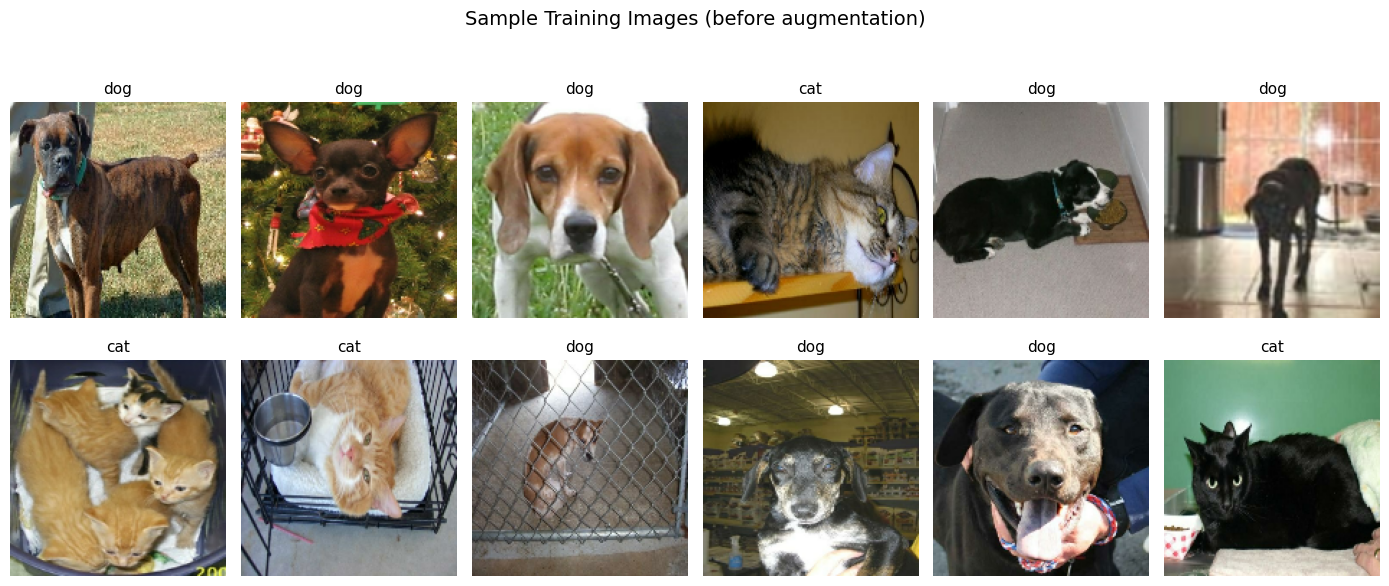

In [6]:
display_ds = raw_train.map(lambda img, lbl: (tf.image.resize(img, IMG_SIZE), lbl))
images, labels = next(iter(display_ds.batch(12)))

plt.figure(figsize=(14, 6))
for i in range(12):
    plt.subplot(2, 6, i + 1)
    plt.imshow(images[i].numpy().astype('uint8'))
    plt.title(CLASS_NAMES[labels[i].numpy()], fontsize=11)
    plt.axis('off')
plt.suptitle('Sample Training Images (before augmentation)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

Build the Model

In [7]:
#   Architecture:
#     Input (150x150x3)
#       └─► VGG16 Conv Layers  [FROZEN — ImageNet weights]
#             └─► GlobalAveragePooling2D
#                   └─► Dense(256, ReLU) + Dropout(0.5)
#                         └─► Dense(128, ReLU) + Dropout(0.3)
#                               └─► Dense(2, Softmax)  ← cat / dog
# ─────────────────────────────────────────────────────────────────────────────

base_model = VGG16(
    weights='imagenet',
    include_top=False,           # exclude original FC layers
    input_shape=(*IMG_SIZE, 3)
)

# Freeze all conv layers — preserve ImageNet features
base_model.trainable = False
frozen_count = sum(1 for l in base_model.layers if not l.trainable)
print(f"VGG16 layers frozen : {frozen_count}/{len(base_model.layers)}")

# Custom classification head
x      = base_model.output
x      = GlobalAveragePooling2D(name='gap')(x)
x      = Dense(256, activation='relu', name='fc1')(x)
x      = Dropout(0.5, name='drop1')(x)
x      = Dense(128, activation='relu', name='fc2')(x)
x      = Dropout(0.3, name='drop2')(x)
output = Dense(NUM_CLASSES, activation='softmax', name='predictions')(x)

model = Model(inputs=base_model.input, outputs=output, name='VGG16_CatDog')

# Compile — SGD with momentum as specified in the assignment
model.compile(
    optimizer=SGD(learning_rate=0.001, momentum=0.9),
    loss='sparse_categorical_crossentropy',   # integer labels (0=cat, 1=dog)
    metrics=['accuracy']
)

model.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
VGG16 layers frozen : 19/19


Model: "VGG16_CatDog"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 150, 150, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 150, 150, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 75, 75, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 75, 75, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 75, 75, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 37, 37, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 37, 37, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 37, 37, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 37, 37, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 18, 18, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 18, 18, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 18, 18, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 18, 18, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 9, 9, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 9, 9, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 9, 9, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 9, 9, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 4, 4, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gap (GlobalAveragePooling2D)    │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop1 (Dropout)                 │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc2 (Dense)                     │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop2 (Dropout)                 │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 2)              │           25

 Total params: 14,879,170 (56.76 MB)

 Trainable params: 164,482 (642.51 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

Train the Model

In [8]:
callbacks = [
    EarlyStopping(
        monitor='val_accuracy',
        patience=4,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=2,
        min_lr=1e-6,
        verbose=1
    ),
    ModelCheckpoint(
        filepath='best_model.keras',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )
]

history = model.fit(
    train_ds,
    epochs=EPOCHS,
    validation_data=val_ds,
    callbacks=callbacks,
    verbose=1
)

print("\n✅ Training complete!")

Epoch 1/20
582/582 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step - accuracy: 0.8861 - loss: 0.6403
Epoch 1: val_accuracy improved from None to 0.96862, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
582/582 ━━━━━━━━━━━━━━━━━━━━ 98s 138ms/step - accuracy: 0.9221 - loss: 0.2974 - val_accuracy: 0.9686 - val_loss: 0.0817 - learning_rate: 0.0010
Epoch 2/20
582/582 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step - accuracy: 0.9487 - loss: 0.1266
Epoch 2: val_accuracy did not improve from 0.96862
582/582 ━━━━━━━━━━━━━━━━━━━━ 70s 116ms/step - accuracy: 0.9499 - loss: 0.1288 - val_accuracy: 0.9656 - val_loss: 0.0870 - learning_rate: 0.0010
Epoch 3/20
582/582 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step - accuracy: 0.9561 - loss: 0.1190
Epoch 3: val_accuracy did not improve from 0.96862
582/582 ━━━━━━━━━━━━━━━━━━━━ 71s 116ms/step - accuracy: 0.9548 - loss: 0.1167 - val_accuracy: 0.9669 - val_loss: 0.0811 - learning_rate: 0.0010
Epoch 4/20
582/582 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step - accuracy

Plot Training History

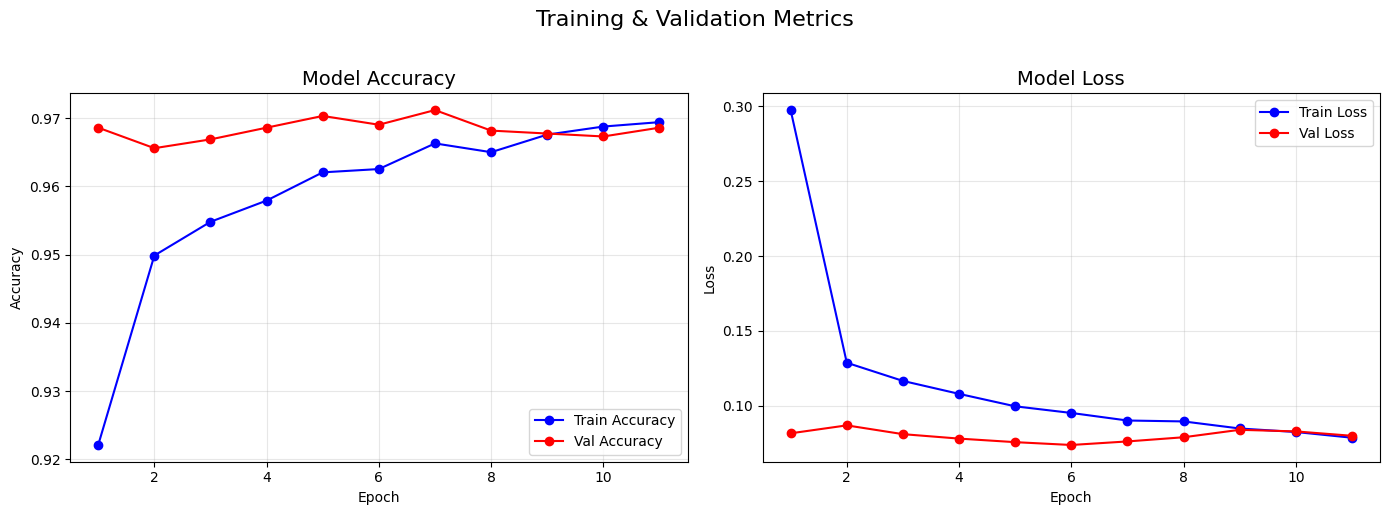

In [9]:
def plot_history(hist):
    acc      = hist.history['accuracy']
    val_acc  = hist.history['val_accuracy']
    loss     = hist.history['loss']
    val_loss = hist.history['val_loss']
    epochs_range = range(1, len(acc) + 1)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(epochs_range, acc,     'b-o', label='Train Accuracy')
    axes[0].plot(epochs_range, val_acc, 'r-o', label='Val Accuracy')
    axes[0].set_title('Model Accuracy', fontsize=14)
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(epochs_range, loss,     'b-o', label='Train Loss')
    axes[1].plot(epochs_range, val_loss, 'r-o', label='Val Loss')
    axes[1].set_title('Model Loss', fontsize=14)
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.suptitle('Training & Validation Metrics', fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()

plot_history(history)

Evaluate on the Test Set


  Test Accuracy : 97.76%
  Test Loss     : 0.0658

Classification Report:
              precision    recall  f1-score   support

         cat       0.99      0.97      0.98      1160
         dog       0.97      0.99      0.98      1166

    accuracy                           0.98      2326
   macro avg       0.98      0.98      0.98      2326
weighted avg       0.98      0.98      0.98      2326



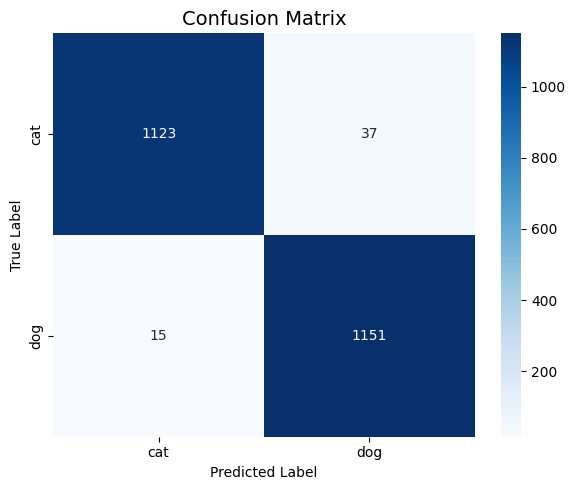

In [10]:
model.load_weights('best_model.keras')

test_loss, test_acc = model.evaluate(test_ds, verbose=0)
print(f"\n{'='*40}")
print(f"  Test Accuracy : {test_acc*100:.2f}%")
print(f"  Test Loss     : {test_loss:.4f}")
print(f"{'='*40}")

# Classification Report & Confusion Matrix
y_true, y_pred = [], []

for imgs, lbls in test_ds:
    preds = model.predict(imgs, verbose=0)
    y_pred.extend(np.argmax(preds, axis=1))
    y_true.extend(lbls.numpy())

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES
)
plt.title('Confusion Matrix', fontsize=14)
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

Predict on New Images

In [13]:
def predict_image(img_path: str) -> dict:
    """
    Classify a single image as 'cat' or 'dog'.

    Parameters
    ----------
    img_path : str
        Local path to the image file (JPEG, PNG, etc.)

    Returns
    -------
    dict with keys: predicted_class, confidence, all_probabilities
    """
    img       = load_img(img_path, target_size=IMG_SIZE)
    img_array = img_to_array(img)                         # (150, 150, 3)
    img_array = np.expand_dims(img_array, axis=0)         # (1, 150, 150, 3)
    img_array = preprocess_input(img_array)

    probs     = model.predict(img_array, verbose=0)[0]    # shape (2,)
    class_idx = np.argmax(probs)

    result = {
        'predicted_class'  : CLASS_NAMES[class_idx],
        'confidence'       : float(probs[class_idx]) * 100,
        'all_probabilities': {cls: float(p) * 100
                              for cls, p in zip(CLASS_NAMES, probs)}
    }

    # Display image with prediction
    plt.figure(figsize=(4, 4))
    plt.imshow(mpimg.imread(img_path))
    title_color = '#2196F3' if result['predicted_class'] == 'cat' else '#FF5722'
    plt.title(
        f"Prediction : {result['predicted_class'].upper()}\n"
        f"Confidence : {result['confidence']:.1f}%",
        fontsize=13, color=title_color, fontweight='bold'
    )
    plt.axis('off')
    plt.tight_layout()
    plt.show()

    # Probability bar chart
    fig, ax = plt.subplots(figsize=(5, 2))
    colors = ['#2196F3', '#FF5722']
    bars   = ax.barh(CLASS_NAMES, [probs[0]*100, probs[1]*100],
                     color=colors, height=0.4)
    ax.set_xlim(0, 100)
    ax.set_xlabel('Probability (%)')
    ax.set_title('Class Probabilities')
    for bar, p in zip(bars, probs):
        ax.text(bar.get_width() + 1,
                bar.get_y() + bar.get_height() / 2,
                f'{p*100:.1f}%', va='center', fontsize=11)
    plt.tight_layout()
    plt.show()

    return result

Upload an image to classify:


Saving sample image 2.jfif to sample image 2.jfif


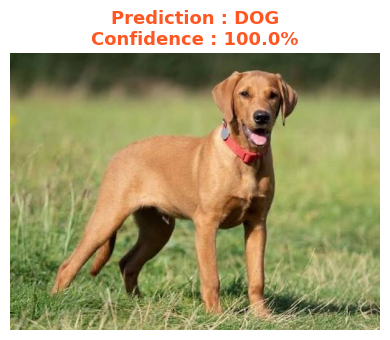

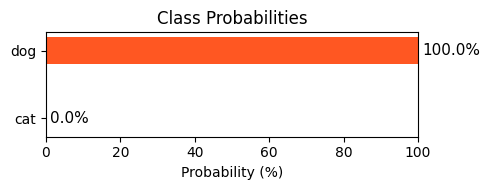


Result: {'predicted_class': 'dog', 'confidence': 100.0, 'all_probabilities': {'cat': 1.8064262972695413e-13, 'dog': 100.0}}


In [14]:
#Upload from your machine

from google.colab import files

print("Upload an image to classify:")
uploaded = files.upload()

if uploaded:
    for filename in uploaded:
        result = predict_image(filename)
        print(f"\nResult: {result}")

Fine-Tune VGG16 Block 5

Trainable layers after unfreezing block5: 10
Epoch 1/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step - accuracy: 0.9670 - loss: 0.0860
Epoch 1: val_accuracy improved from None to 0.97334, saving model to best_finetuned_model.keras

Epoch 1: finished saving model to best_finetuned_model.keras
582/582 ━━━━━━━━━━━━━━━━━━━━ 87s 134ms/step - accuracy: 0.9679 - loss: 0.0845 - val_accuracy: 0.9733 - val_loss: 0.0699 - learning_rate: 1.0000e-04
Epoch 2/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step - accuracy: 0.9745 - loss: 0.0656
Epoch 2: val_accuracy did not improve from 0.97334
582/582 ━━━━━━━━━━━━━━━━━━━━ 77s 129ms/step - accuracy: 0.9747 - loss: 0.0646 - val_accuracy: 0.9686 - val_loss: 0.0829 - learning_rate: 1.0000e-04
Epoch 3/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step - accuracy: 0.9796 - loss: 0.0539
Epoch 3: val_accuracy improved from 0.97334 to 0.97764, saving model to best_finetuned_model.keras

Epoch 3: finished saving model to best_finetuned_model.keras
582/582 ━━━━━━━━━━━━━━━━━

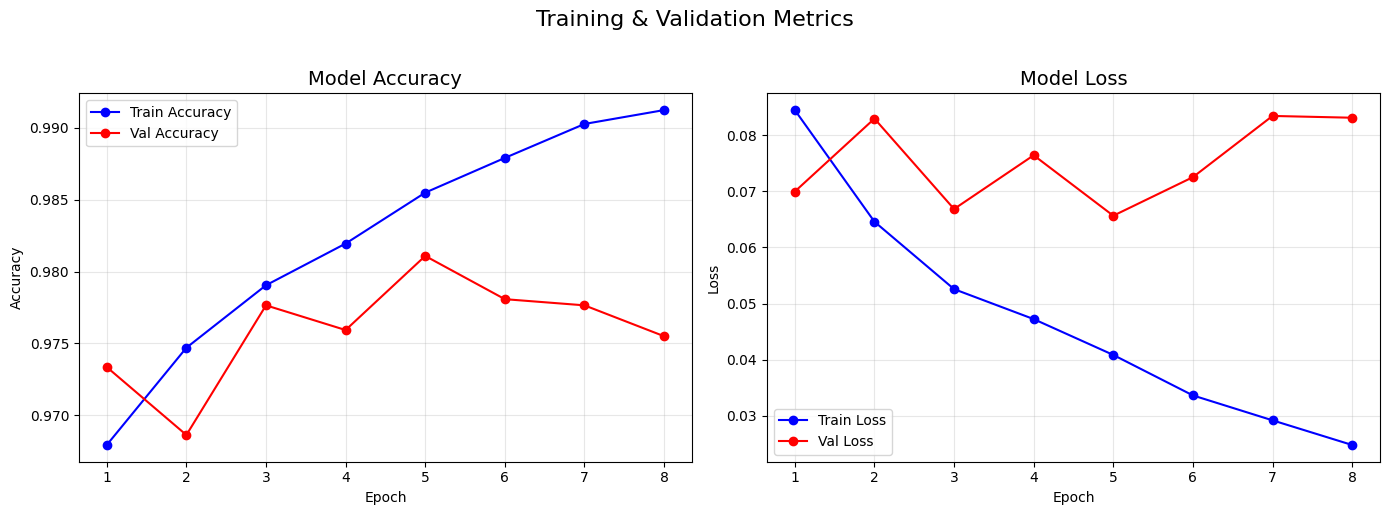


Fine-Tuned Test Accuracy : 98.28%
Fine-Tuned Test Loss     : 0.0602


In [16]:
#   Unfreeze block5 and retrain at a very low LR for an extra ~2-5% accuracy.

for layer in base_model.layers:
    if layer.name.startswith('block5'):
        layer.trainable = True

trainable_count = sum(1 for l in model.layers if l.trainable)
print(f"Trainable layers after unfreezing block5: {trainable_count}")

model.compile(
    optimizer=SGD(learning_rate=1e-4, momentum=0.9),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

fine_tune_callbacks = [
    EarlyStopping(monitor='val_accuracy', patience=3,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                      patience=2, min_lr=1e-7, verbose=1),
    ModelCheckpoint('best_finetuned_model.keras',
                    monitor='val_accuracy', save_best_only=True, verbose=1)
]

history_ft = model.fit(
    train_ds,
    epochs=10,
    validation_data=val_ds,
    callbacks=fine_tune_callbacks,
    verbose=1
)

plot_history(history_ft)

test_loss_ft, test_acc_ft = model.evaluate(test_ds, verbose=0)
print(f"\nFine-Tuned Test Accuracy : {test_acc_ft*100:.2f}%")
print(f"Fine-Tuned Test Loss     : {test_loss_ft:.4f}")

Save & Export the Final Model

In [17]:
model.save('cat_dog_vgg16_final.keras')
print("Model saved  →  cat_dog_vgg16_final.keras")

model.export('cat_dog_savedmodel')
print("SavedModel exported  →  cat_dog_savedmodel/")

from google.colab import files
files.download('cat_dog_vgg16_final.keras')

Model saved  →  cat_dog_vgg16_final.keras
Saved artifact at 'cat_dog_savedmodel'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 150, 150, 3), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 2), dtype=tf.float32, name=None)
Captures:
  136834372678480: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136834372681552: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136834372676560: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136834372680784: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136834372681360: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136834372681168: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136834386526480: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136834386527056: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136834386528016: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136834386527248: TensorSpec(shape=(), dt

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [18]:
# SUMMARY
# ─────────────────────────────────────────────────────────────────────────────
# Step  1  →  Libraries installed, seeds set, constants defined
# Step  2  →  Cats vs Dogs dataset via tensorflow_datasets (no Kaggle needed)
# Step  3  →  tf.data pipelines: VGG16 preprocessing + 5 augmentation ops
# Step  4  →  Frozen VGG16 base + custom head: GAP → 256 → 128 → Softmax(2)
# Step  5  →  Trained with SGD+momentum, EarlyStopping, ReduceLROnPlateau
# Step  6  →  Accuracy & loss curves plotted
# Step  7  →  Test evaluation: accuracy, classification report, confusion matrix
# Step  8  →  predict_image() & predict_from_url() for single-image inference
# Step  9  →  Optional fine-tuning of VGG16 block5 at lr=1e-4
# Step 10  →  Model saved in .keras and SavedModel formats
#
# Expected accuracy:  ~90-95% (frozen base)  |  ~95-97% (after fine-tuning)
# ─────────────────────────────────────────────────────────────────────────────